Graphing the label prevelance

In [1]:
import json
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import hamming_loss, f1_score, precision_score, accuracy_score, recall_score, make_scorer

In [2]:
label_data = pd.read_csv(f"./random_samples.csv", encoding="utf-8") #import labeled data
y = label_data.iloc[:,3:12]
len(y)
np.mean(y.sum(axis=1))
y.sum(axis=0)

party                   21
substance_use            6
sex                     22
romance                  4
braggadocio             26
street_culture          16
humor                    9
social_consciousness    19
introspection           11
dtype: int64

Plot Bar Graphs by Theme for each model

In [3]:
#first, i need to hydrate my predictions
dates = pd.read_json(r'./lyrics-date.json')
dates.loc[dates['era'] == 'Old School', 'date_range'] = "1979 to 1983" #add dates
dates.loc[dates['era'] == 'Golden Age', 'date_range'] = "1983 to 1997"
dates.loc[dates['era'] == 'Bling Era', 'date_range'] = "1997 to 2006"
dates.loc[dates['era'] == 'Blog Era', 'date_range'] = "2006 to 2014"
dates.loc[dates['era'] == 'Rise of Trap', 'date_range'] = "2014 to 2024"

llm_class = pd.read_json(f"./gpt-output/llm_class.json", encoding="utf-8", lines=True, orient='records')
llm_mappings = llm_class.loc[(llm_class['NA'] == False)] #subset for non-NA rows
llm_mappings = llm_mappings.iloc[:,np.r_[1:10, 11]] #only get predictions and id
llm_mappings = llm_mappings.merge(dates, how = 'left', on = 'id').iloc[:,np.r_[0:10, 14:16]] #get the dates

cc_mappings = pd.read_json(r'feature-mappings.json', lines=True, orient='records') #classifier chain
df2 = pd.DataFrame(cc_mappings["prediction"].to_list(), columns=list(llm_mappings.columns[0:9])) #convert to columns
df2['id'] = cc_mappings['id'] #get the ids
df2 = df2.merge(dates, how = 'left', on = 'id').iloc[:,np.r_[0:10, 14:16]] #get the dates
df2 = df2.groupby(['era', 'date_range']).sum().reset_index()

In [4]:
#long data needed

melted = df2.melt(id_vars=['era', 'date_range'], 
                 value_vars=list(df2.iloc[:,1:11].columns),
                 var_name='theme',
                 value_name='count')


<Figure size 1600x800 with 0 Axes>

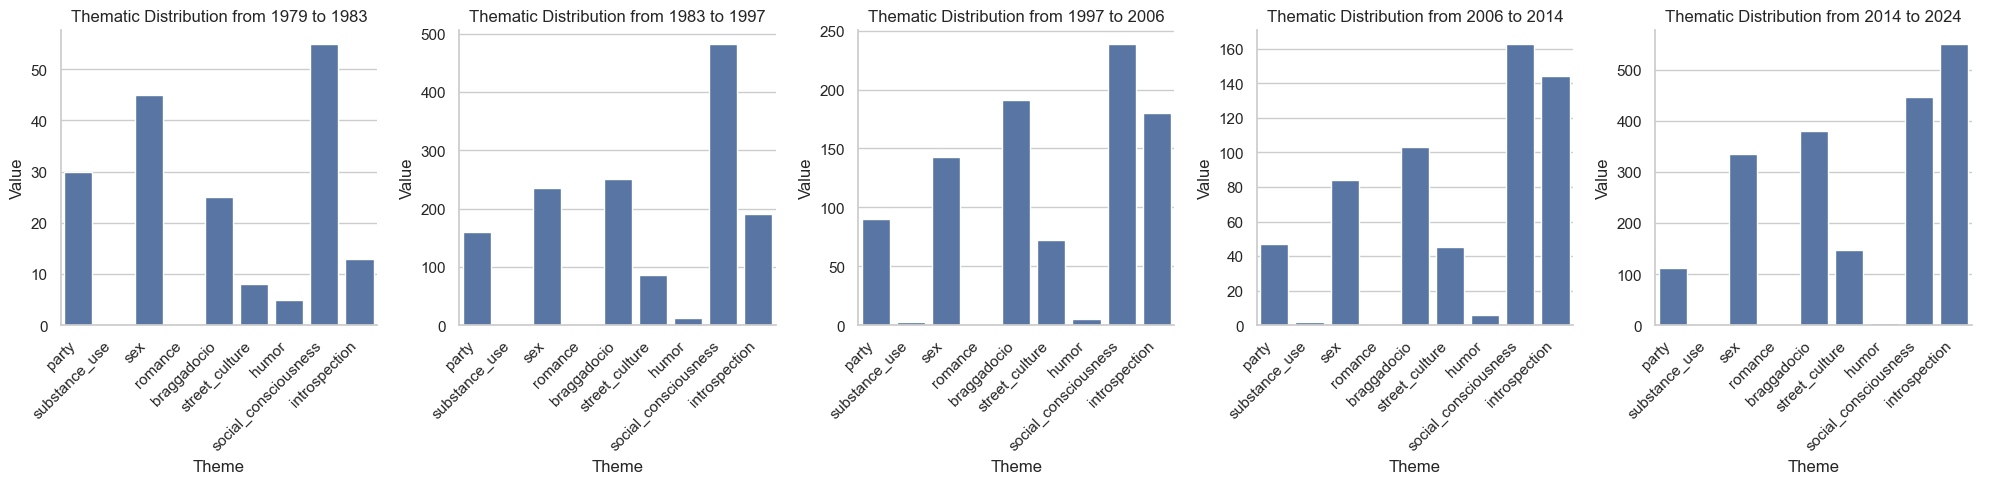

In [5]:
sns.set_theme(style="whitegrid")

# Plot using seaborn's FacetGrid
plt.figure(figsize=(16, 8))
g = sns.FacetGrid(melted, col="date_range", col_wrap=5, #'1979 to 1983', 
                  sharey=False, height=4, col_order=['1979 to 1983','1983 to 1997', '1997 to 2006', '2006 to 2014', '2014 to 2024']) #, col_order=['Golden Age', 'Bling Era', 'Blog Era', 'Rise of Trap']
g.map_dataframe(sns.barplot, x="theme", y="count", dodge=False)
g.set_titles(col_template="Thematic Distribution from {col_name}")
sns.set_theme(font_scale=0.5)
for ax in g.axes.flatten():
    ax.set_xlabel("Theme")
    ax.set_ylabel("Value")
    ax.tick_params(axis='x')
g.set_xticklabels(rotation=45, horizontalalignment='right')
g.add_legend()
#plt.tight_layout()
plt.show()

In [6]:
llm_mappings = llm_mappings.groupby(['era', 'date_range']).sum().reset_index()
#long data needed

melted = llm_mappings.melt(id_vars=['era', 'date_range'], 
                 value_vars=list(llm_mappings.iloc[:,1:11].columns),
                 var_name='theme',
                 value_name='count')

In [7]:
# Calculate total count per era
melted['total_in_era'] = melted.groupby('era')['count'].transform('sum')
# Calculate within-group proportion
melted['within_group_proportion'] = melted['count'] / melted['total_in_era']
# Optional: round for readability
melted['within_group_proportion'] = melted['within_group_proportion'].round(3)
#melted['puerile'] = melted[~melted['theme'].isin(['social_consciousness', 'introspection'])]

In [8]:
melted.sort_values(['era', 'theme'])

,era,date_range,theme,count,total_in_era,within_group_proportion
20,Bling Era,1997 to 2006,braggadocio,563,2607,0.216
30,Bling Era,1997 to 2006,humor,248,2607,0.095
40,Bling Era,1997 to 2006,introspection,171,2607,0.066
0,Bling Era,1997 to 2006,party,354,2607,0.136
15,Bling Era,1997 to 2006,romance,138,2607,0.053
10,Bling Era,1997 to 2006,sex,150,2607,0.058
35,Bling Era,1997 to 2006,social_consciousness,159,2607,0.061
25,Bling Era,1997 to 2006,street_culture,600,2607,0.230
5,Bling Era,1997 to 2006,substance_use,224,2607,0.086
21,Blog Era,2006 to 2014,braggadocio,441,1897,0.232


<Figure size 800x400 with 0 Axes>

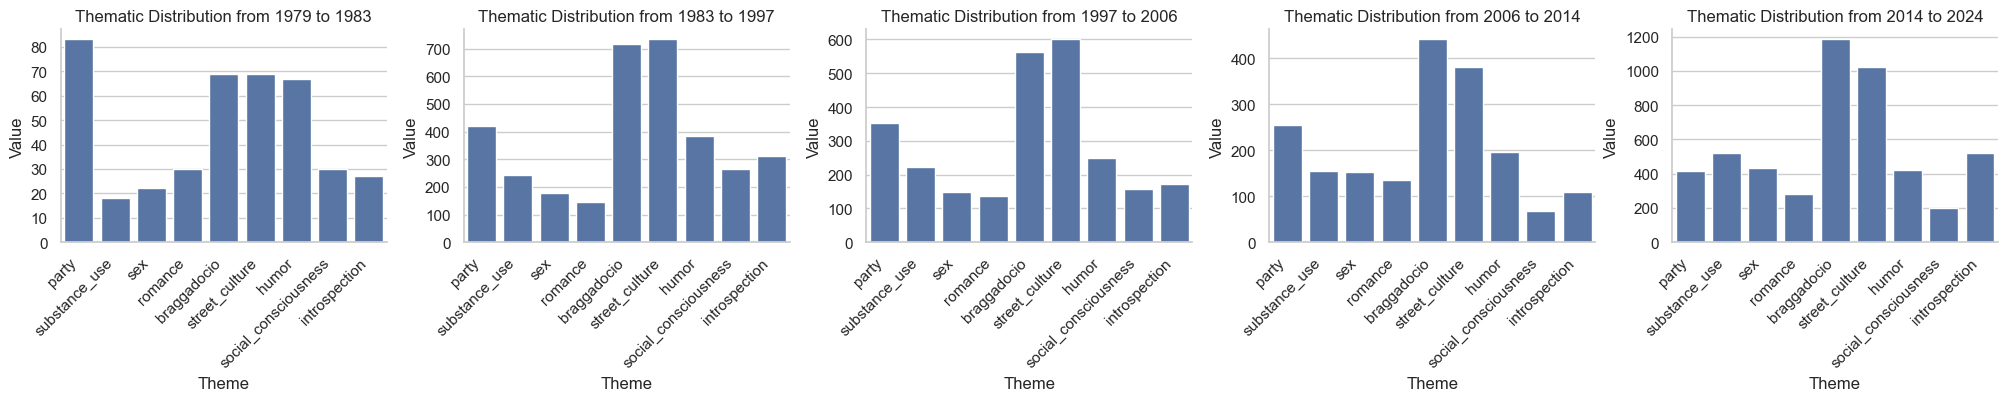

In [9]:
sns.set_theme(style="whitegrid")

# Plot using seaborn's FacetGrid
plt.figure(figsize=(8,4))
g = sns.FacetGrid(melted, col="date_range", col_wrap=5, #'1979 to 1983', 
                  sharey=False, height=4, col_order=['1979 to 1983','1983 to 1997', '1997 to 2006', '2006 to 2014', '2014 to 2024']) #, col_order=['Old School', 'Golden Age', 'Bling Era', 'Blog Era', 'Rise of Trap']
g.map_dataframe(sns.barplot, x="theme", y="count", dodge=False)
g.set_titles(col_template="Thematic Distribution from {col_name}")
sns.set_theme(font_scale=0.5)
for ax in g.axes.flatten():
    ax.set_xlabel("Theme")
    ax.set_ylabel("Value")
    ax.tick_params(axis='x', rotation=45)
g.set_xticklabels(rotation=45, horizontalalignment='right')
g.add_legend()
plt.tight_layout()
plt.show()

Make line graphs for each model's understandings of the theme

In [10]:
#first, i need to hydrate my predictions
dates = pd.read_json(r'./lyrics-date.json')
dates.loc[dates['era'] == 'Old School', 'date_range'] = "1979 to 1983" #add dates
dates.loc[dates['era'] == 'Golden Age', 'date_range'] = "1983 to 1997"
dates.loc[dates['era'] == 'Bling Era', 'date_range'] = "1997 to 2006"
dates.loc[dates['era'] == 'Blog Era', 'date_range'] = "2006 to 2014"
dates.loc[dates['era'] == 'Rise of Trap', 'date_range'] = "2014 to 2024"

In [11]:
llm_class = pd.read_json(f"./gpt-output/llm_class.json", encoding="utf-8", lines=True, orient='records')
llm_mappings = llm_class.loc[(llm_class['NA'] == False)] #subset for non-NA rows
llm_mappings = llm_mappings.iloc[:,np.r_[1:10, 11]] #only get predictions and id
llm_mappings = llm_mappings.merge(dates, how = 'left', on = 'id').iloc[:,np.r_[0:10, 13:16]] #get the dates
numeric_cols = llm_mappings.select_dtypes(include='boolean').columns
llm_mappings = llm_mappings.groupby(llm_mappings.date.dt.year)[numeric_cols].sum()
#llm_mappings = llm_mappings.drop(llm_mappings[llm_mappings.index < 1988].index)

Text(0.5, 1.0, 'LLM Theme Change over Time')

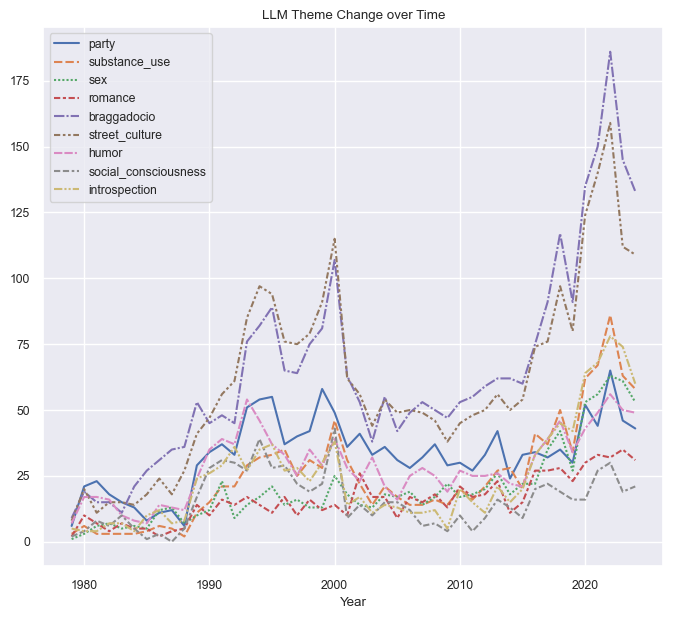

In [12]:
plt.figure(figsize=(8,7))
sns.set_theme(font_scale=0.8)
sns.lineplot(data=llm_mappings)
plt.xlabel("Year")
ax.set_xlim(1983, 2024)
plt.title("LLM Theme Change over Time")

In [13]:
cc_mappings = pd.read_json(r'feature-mappings.json', lines=True, orient='records') #classifier chain
df2 = pd.DataFrame(cc_mappings["prediction"].to_list(), columns=list(llm_mappings.columns[0:9])) #convert to columns
df2['id'] = cc_mappings['id'] #get the ids
df2 = df2.merge(dates, how = 'left', on = 'id').iloc[:,np.r_[0:10, 13:16]] #get the dates
#df2 = df2.groupby(['era', 'date_range']).sum().reset_index()
numeric_cols = df2.select_dtypes(include='number').columns
df2 = df2.groupby(df2.date.dt.year)[numeric_cols].sum()

Text(0.5, 1.0, 'Classifier Chain Theme Change over Time')

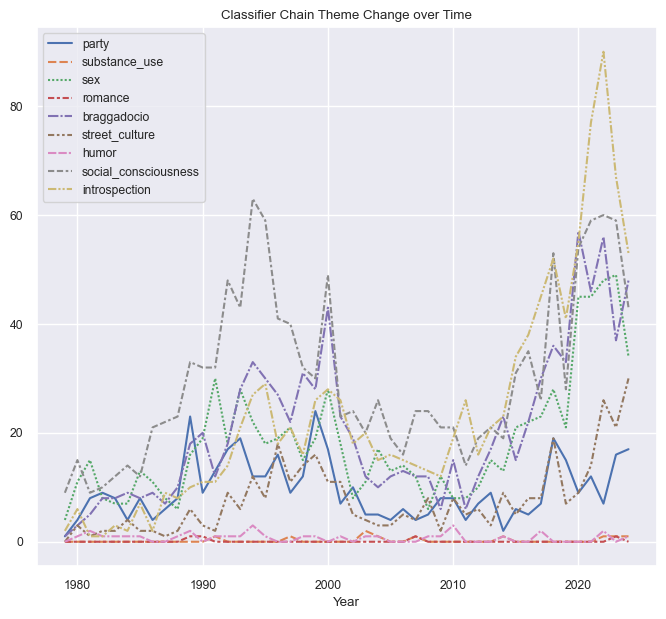

In [14]:
plt.figure(figsize=(8,7))
sns.set_theme(font_scale=0.8)
sns.lineplot(data=df2)
plt.xlabel("Year")
ax.set_xlim(1983, 2024)
plt.title("Classifier Chain Theme Change over Time")

Bar graphs to understand the puerile rap scene

In [15]:
#first, i need to hydrate my predictions
dates = pd.read_json(r'./lyrics-date.json')
dates.loc[dates['era'] == 'Old School', 'date_range'] = "1979 to 1983" #add dates
dates.loc[dates['era'] == 'Golden Age', 'date_range'] = "1983 to 1997"
dates.loc[dates['era'] == 'Bling Era', 'date_range'] = "1997 to 2006"
dates.loc[dates['era'] == 'Blog Era', 'date_range'] = "2006 to 2014"
dates.loc[dates['era'] == 'Rise of Trap', 'date_range'] = "2014 to 2024"

In [16]:
llm_class = pd.read_json(f"./gpt-output/llm_class.json", encoding="utf-8", lines=True, orient='records')
llm_mappings = llm_class.loc[(llm_class['NA'] == False)] #subset for non-NA rows
llm_mappings = llm_mappings.iloc[:,np.r_[1:10, 11]] #only get predictions and id
llm_mappings = llm_mappings.merge(dates, how = 'left', on = 'id').iloc[:,np.r_[0:10, 13:16]] #get the dates
#numeric_cols = llm_mappings.select_dtypes(include='boolean').columns
#llm_mappings = llm_mappings.groupby(llm_mappings.date.dt.year)[numeric_cols].sum()

In [17]:
llm_mappings['puerile'] = (llm_mappings['social_consciousness'] == False) & (llm_mappings['introspection'] == False)
llm_mappings['not_puerile'] = (llm_mappings['social_consciousness'] == True) | (llm_mappings['introspection'] == True)

In [18]:
numeric_cols = llm_mappings.select_dtypes(include='boolean').columns
llm_mappings = llm_mappings.groupby('era')[numeric_cols].sum()

In [19]:
llm_mappings.reset_index()

,era,party,substance_use,sex,romance,braggadocio,street_culture,humor,social_consciousness,introspection,puerile,not_puerile
0,Bling Era,354,224,150,138,563,600,248,159,171,479,247
1,Blog Era,254,156,152,136,441,382,197,69,110,402,141
2,Golden Age,420,242,179,144,717,733,384,265,310,639,436
3,Old School,83,18,22,30,69,69,67,30,27,112,44
4,Rise of Trap,414,518,434,281,1183,1025,420,199,523,975,599


In [20]:
llm_mappings['puerile'] / (llm_mappings['puerile'] + llm_mappings['not_puerile'])

era
Bling Era       0.659780
Blog Era        0.740331
Golden Age      0.594419
Old School      0.717949
Rise of Trap    0.619441
dtype: float64

In [21]:
# set the figure size
plt.figure(figsize=(8, 8))
pnp_llm = pd.DataFrame()
# from raw value to percentage
pnp_llm['total_pure'] = llm_mappings['puerile'] / (llm_mappings['puerile'] + llm_mappings['not_puerile'])
pnp_llm['not_pure'] = llm_mappings['not_puerile'] / (llm_mappings['puerile'] + llm_mappings['not_puerile'])
pnp_llm = pnp_llm.reset_index()

<Figure size 800x800 with 0 Axes>

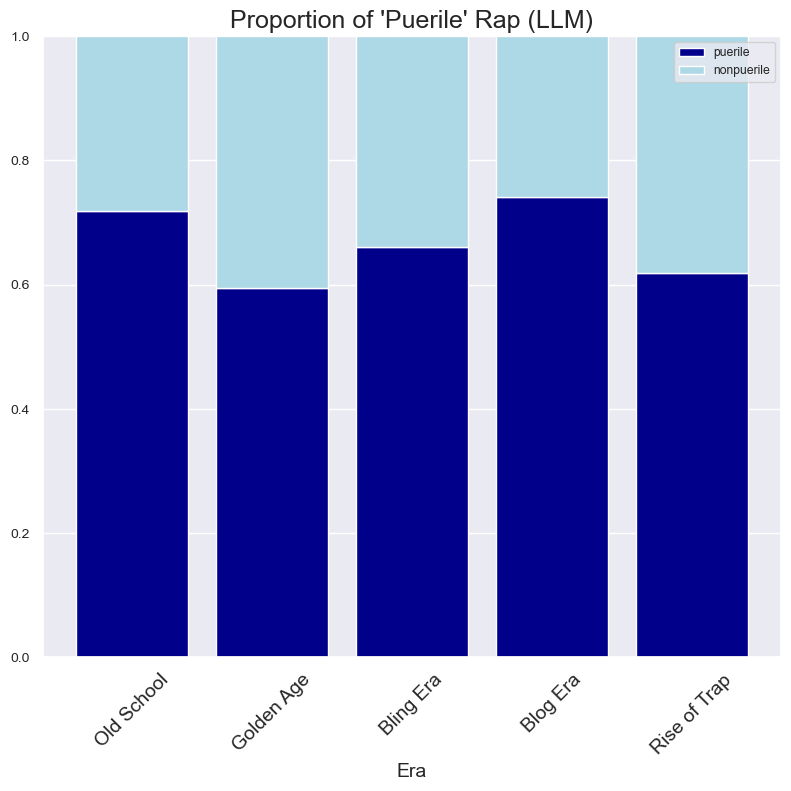

In [22]:
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=10)    # fontsize of the tick labels

plt.figure(figsize=(8, 8))
custom_order = ['Old School', 'Golden Age', 'Bling Era', 'Blog Era', 'Rise of Trap']
#custom_order = ['Golden Age', 'Bling Era', 'Blog Era', 'Rise of Trap']
pnp_llm = pnp_llm.set_index('era').loc[custom_order].reset_index()

plt.bar(pnp_llm['era'], pnp_llm['total_pure'], color='darkblue', label='puerile') #['Old School', 'Golden Age', 'Bling Era', 'Blog Era', 'Rise of Trap']
plt.bar(pnp_llm['era'], pnp_llm['not_pure'], bottom=pnp_llm['total_pure'], color='lightblue', label='nonpuerile')

# Set y-axis from 0 to 1
plt.ylim(0, 1.0)

# Labels and legend
plt.xlabel("Era", fontsize=14)
plt.title("Proportion of 'Puerile' Rap (LLM)", fontsize=18)
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
cc_mappings = pd.read_json(r'feature-mappings.json', lines=True, orient='records') #classifier chain
df2 = pd.DataFrame(cc_mappings["prediction"].to_list(), columns=list(llm_mappings.columns[0:9])) #convert to columns
df2['id'] = cc_mappings['id'] #get the ids
df2 = df2.merge(dates, how = 'left', on = 'id').iloc[:,np.r_[0:10, 14:16]] #get the dates
#df2 = df2.groupby(['era', 'date_range']).sum().reset_index()

In [28]:
df2['puerile'] = (df2['social_consciousness'] == False) & (df2['introspection'] == False)
df2['not_puerile'] = (df2['social_consciousness'] == True) | (df2['introspection'] == True)

In [31]:
df2.groupby('era').sum().reset_index()

,era,party,substance_use,sex,romance,braggadocio,street_culture,humor,social_consciousness,introspection,puerile,not_puerile
0,Bling Era,90.0,3.0,143.0,0.0,191.0,72.0,5.0,239.0,180.0,576,353
1,Blog Era,47.0,2.0,84.0,1.0,103.0,45.0,6.0,163.0,144.0,408,261
2,Golden Age,160.0,2.0,236.0,2.0,251.0,86.0,12.0,483.0,190.0,748,550
3,Old School,30.0,0.0,45.0,0.0,25.0,8.0,5.0,55.0,13.0,119,57
4,Rise of Trap,113.0,3.0,336.0,1.0,380.0,147.0,5.0,448.0,552.0,1112,810


In [25]:
numeric_cols = df2.select_dtypes(include='boolean').columns
df2 = df2.groupby('era')[numeric_cols].sum()

In [27]:
df2['puerile'] / (df2['puerile'] + df2['not_puerile'])

era
Bling Era       0.620022
Blog Era        0.609865
Golden Age      0.576271
Old School      0.676136
Rise of Trap    0.578564
dtype: float64

In [28]:
import matplotlib.patches as mpatches

# set the figure size
plt.figure(figsize=(8, 8))
pnp_cc = pd.DataFrame()
# from raw value to percentage
pnp_cc['total_pure'] = df2['puerile'] / (df2['puerile'] + df2['not_puerile'])
pnp_cc['not_pure'] = df2['not_puerile'] / (df2['puerile'] + df2['not_puerile'])
pnp_cc = pnp_cc.reset_index()

<Figure size 800x800 with 0 Axes>

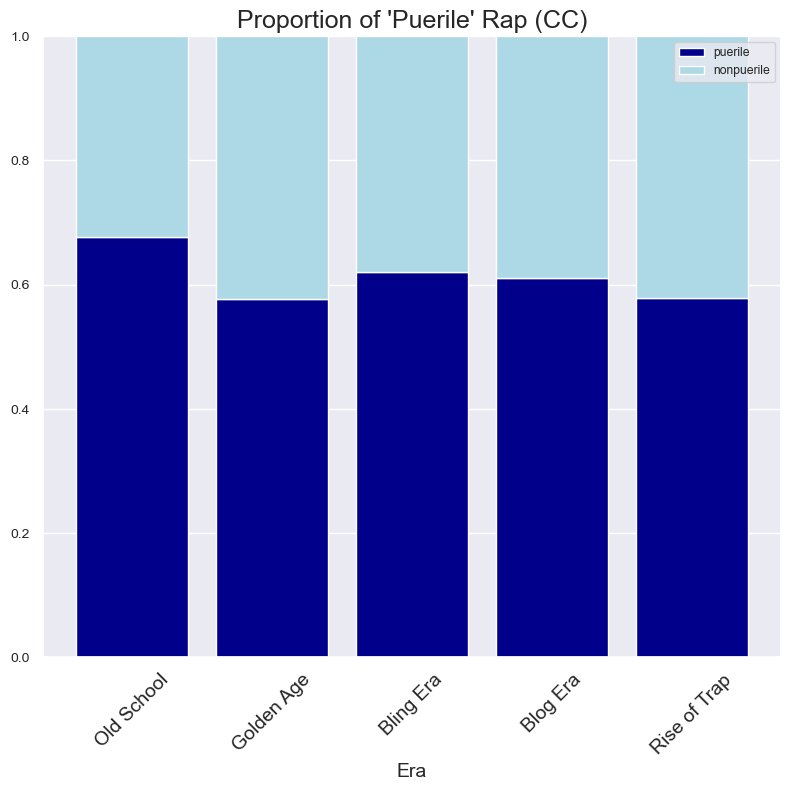

In [29]:
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=10)    # fontsize of the tick labels
plt.figure(figsize=(8, 8))

custom_order = ['Old School','Golden Age', 'Bling Era', 'Blog Era', 'Rise of Trap']
pnp_cc = pnp_cc.set_index('era').loc[custom_order].reset_index()

plt.bar(pnp_cc['era'], pnp_cc['total_pure'], color='darkblue', label='puerile') #['Old School', 'Golden Age', 'Bling Era', 'Blog Era', 'Rise of Trap']
plt.bar(pnp_cc['era'], pnp_cc['not_pure'], bottom=pnp_cc['total_pure'], color='lightblue', label='nonpuerile')

# Set y-axis from 0 to 1
plt.ylim(0, 1.0)

# Labels and legend
plt.xlabel("Era",fontsize=14)
plt.title("Proportion of 'Puerile' Rap (CC)", fontsize=18)
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observing Misclassified Songs

In [67]:
df3 = pd.DataFrame()
themes = [
    'party', 'substance_use', 'sex', 'romance', 'braggadocio',
    'street_culture', 'humor', 'social_consciousness', 'introspection'
]
def extract_themes(row):
    return [col for col in themes if row[col] == True]

In [68]:
llm_class = pd.read_json(f"./gpt-output/llm_class.json", encoding="utf-8", lines=True, orient='records')
llm_mappings = llm_class.loc[(llm_class['NA'] == False) & (llm_class['id'].isin(label_data['id']))] #subset for non-NA rows

In [69]:
llm_class.loc[(llm_class['id'] == '63c69447-954c-5579-b00f-e384e6de831a')]

,summary,party,substance_use,sex,romance,braggadocio,street_culture,humor,social_consciousness,introspection,NA,id,title
4775,The song reflects on the concept of 'friends' ...,False,False,False,False,False,False,True,False,True,False,63c69447-954c-5579-b00f-e384e6de831a,Friends


In [70]:
df3['id'] = label_data.loc[:,'id']
df3['human_rationale'] = label_data.loc[:,'rationale']
df3['human_themes'] = label_data.apply(extract_themes, axis=1)
#label_data.loc[:,['id', 'rationale']]

In [71]:
cc_mappings = pd.read_json(r'feature-mappings.json', lines=True, orient='records') #classifier chain
df2 = pd.DataFrame(cc_mappings["prediction"].to_list(), columns=list(llm_mappings.columns[1:10])) #convert to columns
df2['id'] = cc_mappings['id'] #get the ids
df2 = df2[df2['id'].isin(df3['id'])]
df2['cc_themes'] = df2.apply(extract_themes, axis=1)
df2 = df2.iloc[:,9:11]

In [72]:
df3 = df3.merge(df2, how = 'left', on = 'id')

In [73]:
llm_mappings = llm_mappings[llm_mappings['id'].isin(df3['id'])]
llm_mappings['llm_themes'] = llm_mappings.apply(extract_themes, axis=1)
llm_mappings = llm_mappings.iloc[:,np.r_[0,11,13]]
df3 = df3.merge(llm_mappings, how = 'right', on = 'id')

In [74]:
df3.to_csv(r'comparisons.csv')

averaging out measures

In [120]:
results = pd.read_json('model_outputs_redo.json', orient='records', lines=True)
results["group"] = results["model"].str.extract(r"(LP|BR|MlKNN|impcorr|random)") # group by model

melted = results.drop(columns=["f1"]).melt(id_vars=["model", "group"], 
                                           var_name="metric", value_name="value") #drop f1, melt

melted.groupby(['group','metric']).mean() #print avg performance

value
group   metric                
BR      accuracy      0.000000
        f1_macro      0.000000
        f1_micro      0.000000
        hamming_loss  0.202116
        precision     0.000000
        recall        0.000000
LP      accuracy      0.028571
        f1_macro      0.039566
        f1_micro      0.128932
        hamming_loss  0.273016
        precision     0.180952
        recall        0.100221
MlKNN   accuracy      0.000000
        f1_macro      0.039683
        f1_micro      0.062150
        hamming_loss  0.224339
        precision     0.193896
        recall        0.037334
impcorr accuracy      0.000000
        f1_macro      0.000000
        f1_micro      0.000000
        hamming_loss  0.202116
        precision     0.000000
        recall        0.000000
random  accuracy      0.000000
        f1_macro      0.000000
        f1_micro      0.000000
        hamming_loss  0.202116
        precision     0.000000
        recall        0.000000

calculate llm performance

In [95]:
y = llm_class[llm_class['id'].isin(label_data['id'])].iloc[:,1:12].merge(label_data, how = 'left', on = 'id')

In [115]:
y_true = y.iloc[:,13:22]
y_true.columns = label_data.iloc[:,3:12].columns

In [108]:
y_pred = y.iloc[:,0:9]
y_pred.columns = label_data.iloc[:,3:12].columns

In [116]:
ham_loss = hamming_loss(y_true, y_pred)
micro = f1_score(y_true, y_pred, average='micro')
macro = f1_score(y_true, y_pred, average='macro')
uncombined = f1_score(y_true, y_pred, average=None)
prec = precision_score(y_true, y_pred, average='micro', zero_division=0)
recall = recall_score(y_true, y_pred, average='micro')
acc = accuracy_score(y_true, y_pred)

In [119]:
y_pred.columns

Index(['party', 'substance_use', 'sex', 'romance', 'braggadocio',
       'street_culture', 'humor', 'social_consciousness', 'introspection'],
      dtype='object')

In [117]:
print("Hamming Loss: ", ham_loss,
          "\nF1 Micro: ", micro,
          "\nF1 Macro: ", macro,
          "\nF1: ", uncombined.tolist(),
          "\nPrecision: ", prec,
          "\nRecall: ", recall,
          "\nAccuracy: ",acc)

Hamming Loss:  0.31241830065359477 
F1 Micro:  0.4213075060532688 
F1 Macro:  0.4233484702819287 
F1:  [0.3859649122807018, 0.2, 0.7000000000000001, 0.5714285714285715, 0.4675324675324675, 0.4225352112676056, 0.20833333333333334, 0.6190476190476191, 0.2352941176470588] 
Precision:  0.3118279569892473 
Recall:  0.6492537313432836 
Accuracy:  0.047058823529411764


In [121]:
llm_class = llm_class.loc[(llm_class['NA'] == False)] #subset for non-NA rows
y = llm_class[llm_class['id'].isin(label_data['id'])].iloc[:,1:12].merge(label_data, how = 'left', on = 'id')
y_true = y.iloc[:,13:22]
y_true.columns = label_data.iloc[:,3:12].columns
y_pred = y.iloc[:,0:9]
y_pred.columns = label_data.iloc[:,3:12].columns
ham_loss = hamming_loss(y_true, y_pred)
micro = f1_score(y_true, y_pred, average='micro')
macro = f1_score(y_true, y_pred, average='macro')
uncombined = f1_score(y_true, y_pred, average=None)
prec = precision_score(y_true, y_pred, average='micro', zero_division=0)
recall = recall_score(y_true, y_pred, average='micro')
acc = accuracy_score(y_true, y_pred)

In [122]:
print("Hamming Loss: ", ham_loss,
          "\nF1 Micro: ", micro,
          "\nF1 Macro: ", macro,
          "\nF1: ", uncombined.tolist(),
          "\nPrecision: ", prec,
          "\nRecall: ", recall,
          "\nAccuracy: ",acc)

Hamming Loss:  0.2962962962962963 
F1 Micro:  0.42499999999999993 
F1 Macro:  0.4207871488635631 
F1:  [0.34146341463414637, 0.19047619047619047, 0.6857142857142857, 0.5454545454545454, 0.4918032786885247, 0.4150943396226415, 0.2162162162162162, 0.625, 0.27586206896551724] 
Precision:  0.3192488262910798 
Recall:  0.6355140186915887 
Accuracy:  0.057971014492753624


chi-square tests